veri yukleme kutup yukleme
verı tıplerı

In [ ]:
# temel veri işleme kütüphaneleri
import pandas as pd
import numpy as np

# görselleştirme kütüphaneleri
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches

#istatistik kütüphaneleri
from scipy import stats
import warnings

# ayarlar
warnings.filterwarnings('ignore') # uyarı mesajlarını kapatır
pd.set_option('display.max_columns', 50)# büyük veri de gelecek columm sayısını sınırlar
pd.set_option('display.max_rows', None)# satırı sınırlar
pd.set_option('display.float_format', lambda x: '%.2f' % x)#ekranda virgülden sonra kaç basamak

#Grafik stili ayarları
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize']= (12,8)
plt.rcParams['font.size']= 12

print('Tüm kütüphaneler başarıyla yüklendi')
print(f'Pandas version: {pd.__version__}')
print(f'Numpy version: {np.__version__}')

print(f'Seaborn version: {sns.__version__}')

Tüm kütüphaneler başarıyla yüklendi
Pandas version: 2.2.2
Numpy version: 2.0.2
Seaborn version: 0.13.2


In [ ]:
df_new= pd.read_csv('/content/netflix_titles_2021.csv')

print(' Netflix Verisi')
print('='*50)
print(f'Boyut : {df_new.shape[0]} satır, {df_new.shape[1]} sütun')
print('='*50)
print(f'Bellek kullanımı: {df_new.memory_usage(deep=True).sum()/1024:.2f} KB')

 Netflix Verisi
Boyut : 8807 satır, 12 sütun
Bellek kullanımı: 7980.25 KB


In [ ]:
#ilk beş satır yaazdırma
df_new.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [ ]:
print('Veri tipleri')
print('='*40)
dtype_df= pd.DataFrame({
    'sütun': df_new.columns,
    'veri tipi': df_new.dtypes.values,
    'null değeri':df_new.isnull().sum().values,
    'null oranı(%)': (df_new.isnull().sum().values/len(df_new)*100).round(2),
    'unıque': df_new.nunique().values
})

print(dtype_df.to_string(index=False))

Veri tipleri
       sütun veri tipi  null değeri  null oranı(%)  unıque
     show_id    object            0           0.00    8807
        type    object            0           0.00       2
       title    object            0           0.00    8807
    director    object         2634          29.91    4528
        cast    object          825           9.37    7692
     country    object          831           9.44     748
  date_added    object           10           0.11    1767
release_year     int64            0           0.00      74
      rating    object            4           0.05      17
    duration    object            3           0.03     220
   listed_in    object            0           0.00     514
 description    object            0           0.00    8775


In [ ]:
df_new.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [ ]:
#  Sayısal değişkenlerie ilgili temel istatistikler
df_new.describe().T

,count,mean,std,min,25%,50%,75%,max
release_year,8807.00,2014.18,8.82,1925.00,2013.00,2017.00,2019.00,2021.00


In [ ]:
#kategorik  değişkenlerin temel istatistikleri
df_new.describe(include=['object','category']).T

,count,unique,top,freq
show_id,8807,8807,s8807,1
type,8807,2,Movie,6131
title,8807,8807,Zubaan,1
director,6173,4528,Rajiv Chilaka,19
cast,7982,7692,David Attenborough,19
country,7976,748,United States,2818
date_added,8797,1767,"January 1, 2020",109
rating,8803,17,TV-MA,3207
duration,8804,220,1 Season,1793
listed_in,8807,514,"Dramas, International Movies",362


In [ ]:
#Eksik Veri Analizi
eksik =df_new.isnull().sum()
eksik_oranı=(eksik/len(df_new)*100).round(2)
eksik_df=pd.concat([eksik,eksik_oranı],axis=1)
eksik_df.columns=["eksik_sayı","eksik_oran"]
eksik_df.sort_values("eksik_oran",ascending=False)

,eksik_sayı,eksik_oran
director,2634,29.91
country,831,9.44
cast,825,9.37
date_added,10,0.11
rating,4,0.05
duration,3,0.03
show_id,0,0.00
type,0,0.00
title,0,0.00
release_year,0,0.00


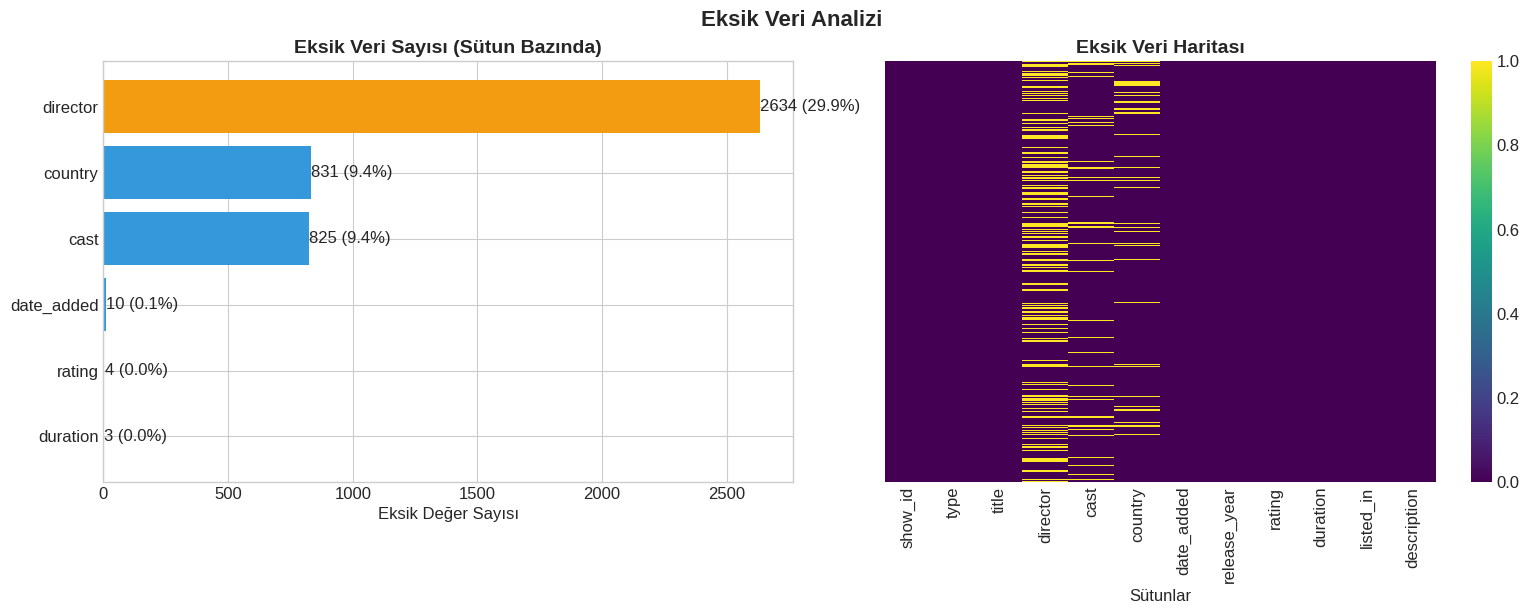

In [ ]:
# Eksik veri görselleştirmesi
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart
eksik_olan = df_new.isnull().sum()
eksik_olan = eksik_olan[eksik_olan > 0].sort_values(ascending=True)

colors = ['#e74c3c' if x > 30 else '#f39c12' if x > 10 else '#3498db'
          for x in (eksik_olan / len(df_new) * 100)]

axes[0].barh(eksik_olan.index, eksik_olan.values, color=colors)
axes[0].set_title('Eksik Veri Sayısı (Sütun Bazında)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Eksik Değer Sayısı')
for i, (val, col) in enumerate(zip(eksik_olan.values, eksik_olan.index)):
    axes[0].text(val + 1, i, f'{val} ({val/len(df_new)*100:.1f}%)', va='center')

# Heatmap
sns.heatmap(df_new.isnull(),
            yticklabels=False,
            cbar=True,
            cmap='viridis',
            ax=axes[1])
axes[1].set_title('Eksik Veri Haritası', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Sütunlar')

plt.tight_layout()
plt.suptitle('Eksik Veri Analizi', fontsize=16, fontweight='bold', y=1.02)
plt.show()

In [ ]:
#aykırı değer fazla olduğunda kullanılır
df_temiz= df_new.copy()

ulke_mode = df_temiz['country'].mode()[0]

df_temiz['country'].fillna(ulke_mode, inplace=True)

df_temiz.isnull().sum()

,0
show_id,0
type,0
title,0
director,2634
cast,825
country,0
date_added,10
release_year,0
rating,4
duration,3


In [ ]:
# 1. En çok tekrar eden yönetmeni bul
en_cok_gecen_yonetmen = df_temiz['director'].mode()[0]

# 2. Boş (null) olan yönetmen değerlerini bu kişiyle doldur
df_temiz['director'].fillna(en_cok_gecen_yonetmen, inplace=True)
print(df_temiz.isnull().sum())

show_id           0
type              0
title             0
director          0
cast            825
country           0
date_added       10
release_year      0
rating            4
duration          3
listed_in         0
description       0
dtype: int64


**Tek değişkenli analiz**

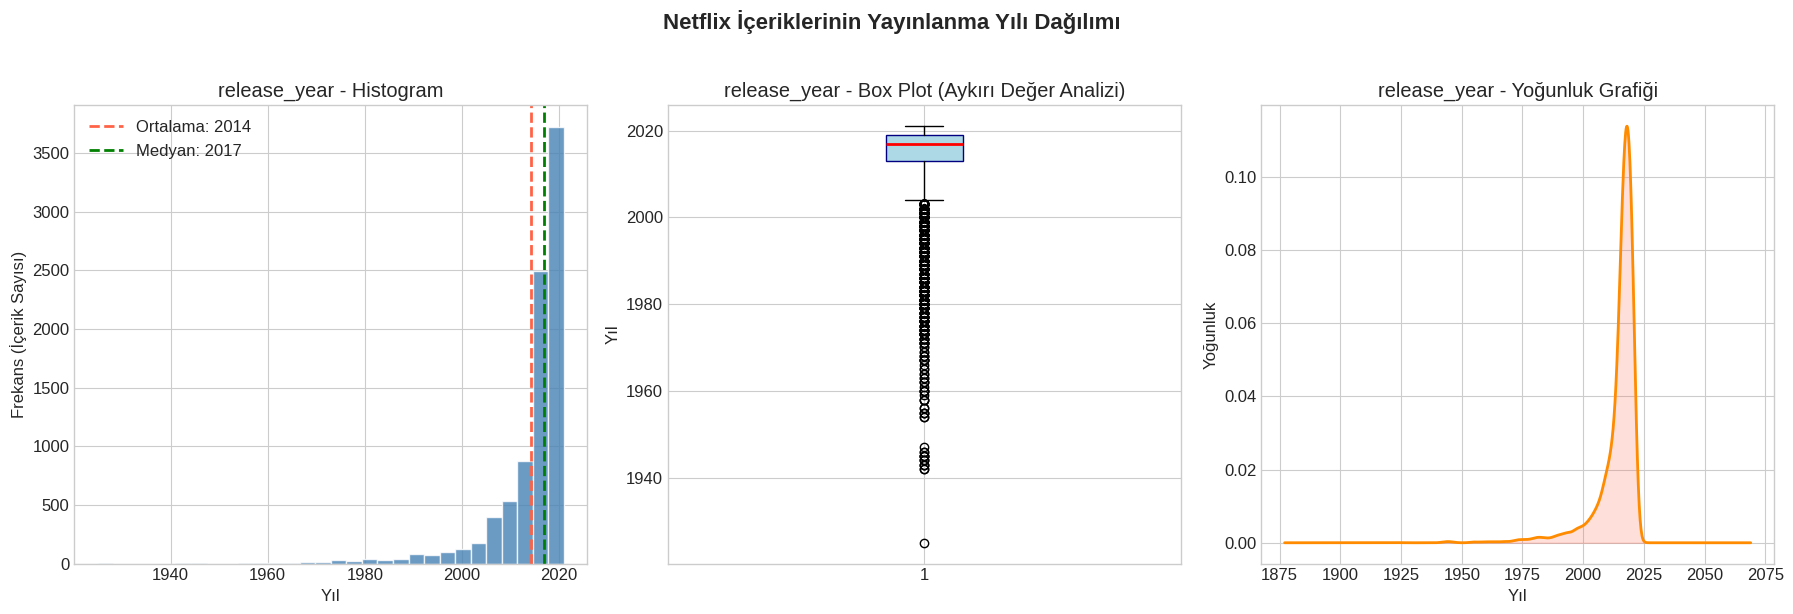

In [ ]:
# sayısal değişkenler
kolon = 'release_year'

# Eksik veri varsa atıyoruz
veri = df_temiz[kolon].dropna()

# 1 satır, 3 sütunluk bir figür oluşturuyoruz
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# 1. Grafik: Histogram (axes[0])
axes[0].hist(veri, bins=30, color="steelblue", edgecolor='white', alpha=0.8)
axes[0].axvline(veri.mean(), color='tomato', linestyle='dashed', linewidth=2, label=f'Ortalama: {veri.mean():.0f}')
axes[0].axvline(veri.median(), color='green', linestyle='dashed', linewidth=2, label=f'Medyan: {veri.median():.0f}')
axes[0].set_title(f'{kolon} - Histogram')
axes[0].legend()
axes[0].set_xlabel('Yıl')
axes[0].set_ylabel('Frekans (İçerik Sayısı)')

# 2. Grafik: Box Plot (Kutu Grafiği) (axes[1])
axes[1].boxplot(veri, vert=True, patch_artist=True,
                boxprops=dict(facecolor='lightblue', color='navy'),
                medianprops=dict(color='red', linewidth=2))
axes[1].set_title(f'{kolon} - Box Plot (Aykırı Değer Analizi)')
axes[1].set_ylabel('Yıl')

# 3. Grafik: KDE (Kümülatif Yoğunluk Grafiği) (axes[2])
veri.plot.kde(ax=axes[2], color='darkorange', linewidth=2)

x_data = axes[2].lines[0].get_xdata()
y_data = axes[2].lines[0].get_ydata()
axes[2].fill_between(x_data, y_data, color='tomato', alpha=0.2)

axes[2].set_title(f'{kolon} - Yoğunluk Grafiği')
axes[2].set_xlabel('Yıl')
axes[2].set_ylabel('Yoğunluk')

# Genel başlık ve düzenleme
plt.suptitle('Netflix İçeriklerinin Yayınlanma Yılı Dağılımı', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# istatiksel özet tablo
sayisal_kolonlar = ['release_year']

print('Sayısal Değişkenler Detaylı İstatistikler:')
print('='*70)

for kolon in sayisal_kolonlar:
    veri = df_temiz[kolon].dropna()

    print(f'\n * {kolon.upper()} (Yayınlanma Yılı)')
    print(f'Ortalama: {veri.mean():.2f}')
    print(f'Medyan: {veri.median():.0f}')
    print(f'Standart Sapma: {veri.std():.2f}')
    print(f'Minimum: {veri.min():.0f}') # Yıl olduğu için tam sayı yaptık
    print(f'Maksimum: {veri.max():.0f}') # Yıl olduğu için tam sayı yaptık
    print(f'Varyans: {veri.var():.2f}')
    print(f'Skewness (Çarpıklık): {veri.skew():.2f}')
    print(f'Kurtosis (Basıklık): {veri.kurtosis():.2f}')
    print(f'IQR: {veri.quantile(0.75) - veri.quantile(0.25):.0f}')
    print('='*70)

Sayısal Değişkenler Detaylı İstatistikler:

 * RELEASE_YEAR (Yayınlanma Yılı)
Ortalama: 2014.18
Medyan: 2017
Standart Sapma: 8.82
Minimum: 1925
Maksimum: 2021
Varyans: 77.78
Skewness (Çarpıklık): -3.45
Kurtosis (Basıklık): 16.23
IQR: 6


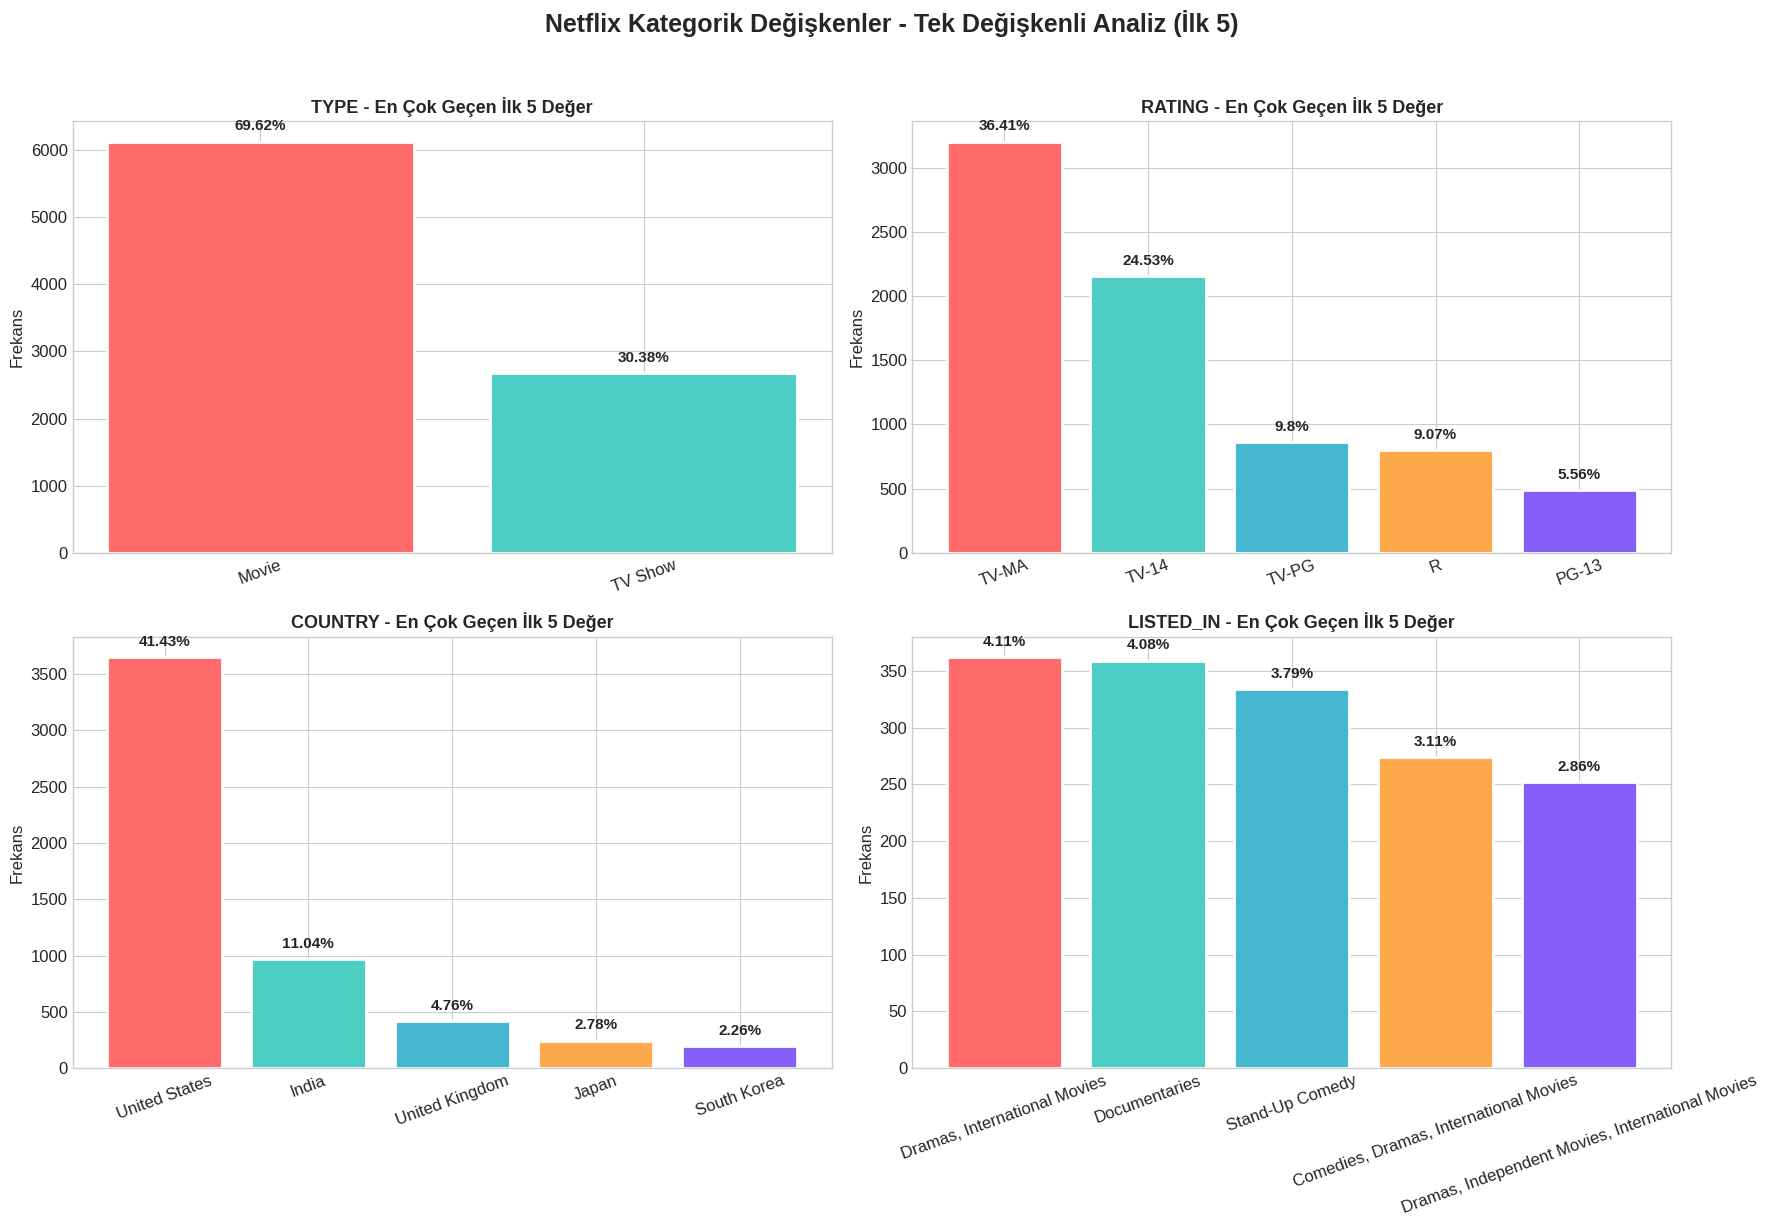

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Kategorik değişkenleri tanımlıyoruz
kategorik_kolonlar = ['type', 'rating', 'country', 'listed_in']

# X eksenindeki isimler uzun olacağı için figsize'ı biraz daha genişlettik (18, 12)
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.flatten()

renkler = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA94D', '#845EF7', '#F06595']

for i, kolon in enumerate(kategorik_kolonlar):

    # sadece "İlk 5" en büyük değeri alıyoruz
    degerler = df_temiz[kolon].value_counts().head(5)

    # Yüzdeyi hesaplıyoruz
    yuzde = (degerler / len(df_temiz) * 100).round(2)

    bars = axes[i].bar(degerler.index.astype(str), degerler.values,
                       color=renkler[:len(degerler)], edgecolor='white', linewidth=2)

    axes[i].set_title(f'{kolon.upper()} - En Çok Geçen İlk 5 Değer', fontsize=13, fontweight='bold')
    axes[i].set_ylabel('Frekans')

    # X eksenindeki yazılar (ülke adları, türler) birbirine girmesin diye 20 derece eğiyoruz
    axes[i].tick_params(axis='x', rotation=20)

    for bar, pct in zip(bars, yuzde.values):
        axes[i].text(bar.get_x() + bar.get_width() / 2,
                     bar.get_height() + (degerler.max() * 0.02), # Yazıların barın üstünde düzgün durması için dinamik boşluk
                     f'{pct}%',
                     ha='center',
                     va='bottom',
                     fontsize=11,
                     fontweight='bold')

plt.suptitle('Netflix Kategorik Değişkenler - Tek Değişkenli Analiz (İlk 5)', fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Çift değişkenli Analiz**

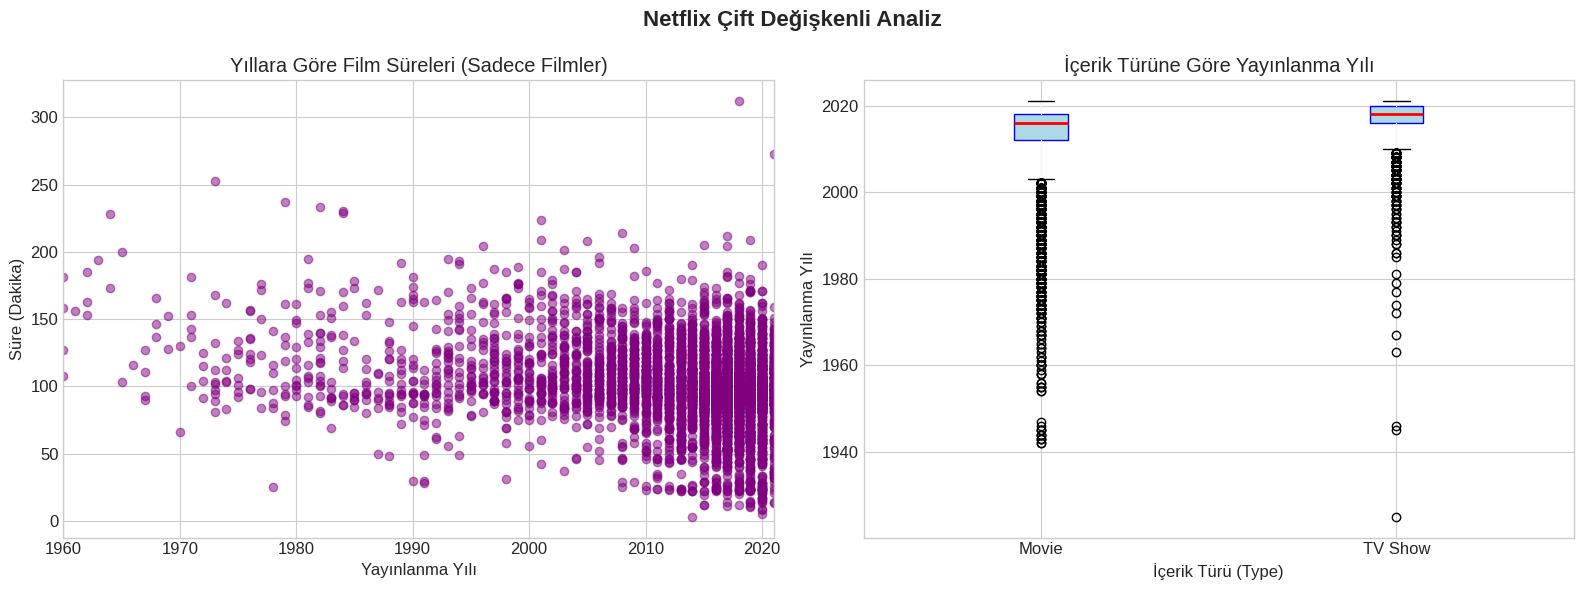

In [ ]:

# VERİ HAZIRLIĞI (Scatter plot için 2. sayısal değişkeni üretiyoruz)
# Sadece Filmleri alıyoruz (Diziler sezon olduğu için süreleri farklıdır)
filmler = df_temiz[df_temiz['type'] == 'Movie'].copy()

# '90 min' gibi metinlerin içindeki ' min' kısmını silip sayıya (float) çeviriyoruz
filmler['süre_dakika'] = filmler['duration'].str.replace(' min', '').astype(float)

# GRAFİK ÇİZİMİ

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Grafik: Yıl vs Film Süresi (Scatter Plot)
axes[0].scatter(filmler['release_year'], filmler['süre_dakika'], color='purple', alpha=0.5)
axes[0].set_xlabel('Yayınlanma Yılı')
axes[0].set_ylabel('Süre (Dakika)')
axes[0].set_title('Yıllara Göre Film Süreleri (Sadece Filmler)')
axes[0].set_xlim(1960, df_temiz['release_year'].max())


# 2. Grafik: Tür(Movie/TV Show) vs Yayınlanma Yılı (Boxplot)
df_temiz.boxplot(column='release_year', by='type', ax=axes[1], patch_artist=True,
                 boxprops=dict(facecolor='lightblue', color='blue'),
                 medianprops=dict(color='red', linewidth=2))

axes[1].set_xlabel('İçerik Türü (Type)')
axes[1].set_ylabel('Yayınlanma Yılı')
axes[1].set_title('İçerik Türüne Göre Yayınlanma Yılı')

# Pandas boxplot default olarak çirkin bir ana başlık atar, onu ezip kendi başlığımızı yazıyoruz
fig.suptitle('Netflix Çift Değişkenli Analiz', fontsize=16, fontweight='bold')

plt.tight_layout()
plt.show()

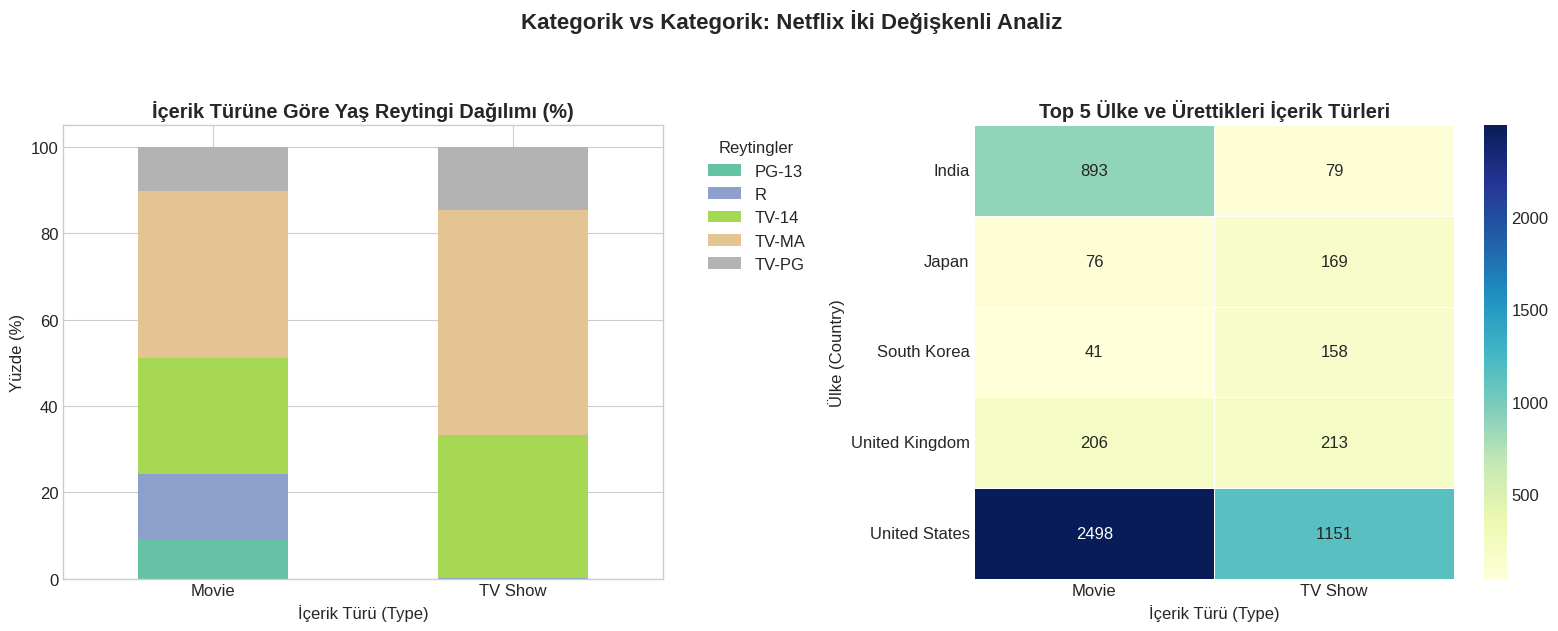

In [ ]:
#Kategorik vs Kategorik Cinsiyet ve hayatta kalma
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. GRAFİK (Stacked Bar): İÇERİK TÜRÜ (Type) vs REYTİNG (Rating)
# Çok fazla reyting olduğu için sadece en çok geçen ilk 5 reytingi alıyoruz
en_populer_reytingler = df_temiz['rating'].value_counts().head(5).index
df_rating = df_temiz[df_temiz['rating'].isin(en_populer_reytingler)]

ct_pct = pd.crosstab(df_rating['type'], df_rating['rating'], normalize='index') * 100

ct_pct.plot(kind='bar', stacked=True, ax=axes[0], colormap='Set2')

axes[0].set_title('İçerik Türüne Göre Yaş Reytingi Dağılımı (%)', fontweight='bold')
axes[0].set_xlabel('İçerik Türü (Type)')
axes[0].set_ylabel('Yüzde (%)')
axes[0].legend(title='Reytingler', bbox_to_anchor=(1.05, 1), loc='upper left') # Legend'ı grafiğin dışına aldık
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)

# 2. GRAFİK (Heatmap): İLK 5 ÜLKE (Country) vs İÇERİK TÜRÜ (Type)
# en çok üreten ilk 5 ülkeyi alıyoruz
en_populer_ulkeler = df_temiz['country'].value_counts().head(5).index
df_ulke = df_temiz[df_temiz['country'].isin(en_populer_ulkeler)]

# Isı haritası için crosstab (sayısal adetleri sayar)
ct2 = pd.crosstab(df_ulke['country'], df_ulke['type'])

# fmt='d' (tam sayı) parametresi ile ısı haritasını çizdiriyoruz
sns.heatmap(ct2, annot=True, fmt='d', cmap='YlGnBu', ax=axes[1], linewidths=.5)

axes[1].set_title('Top 5 Ülke ve Ürettikleri İçerik Türleri', fontweight='bold')
axes[1].set_xlabel('İçerik Türü (Type)')
axes[1].set_ylabel('Ülke (Country)')

plt.suptitle('Kategorik vs Kategorik: Netflix İki Değişkenli Analiz', fontsize=16, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

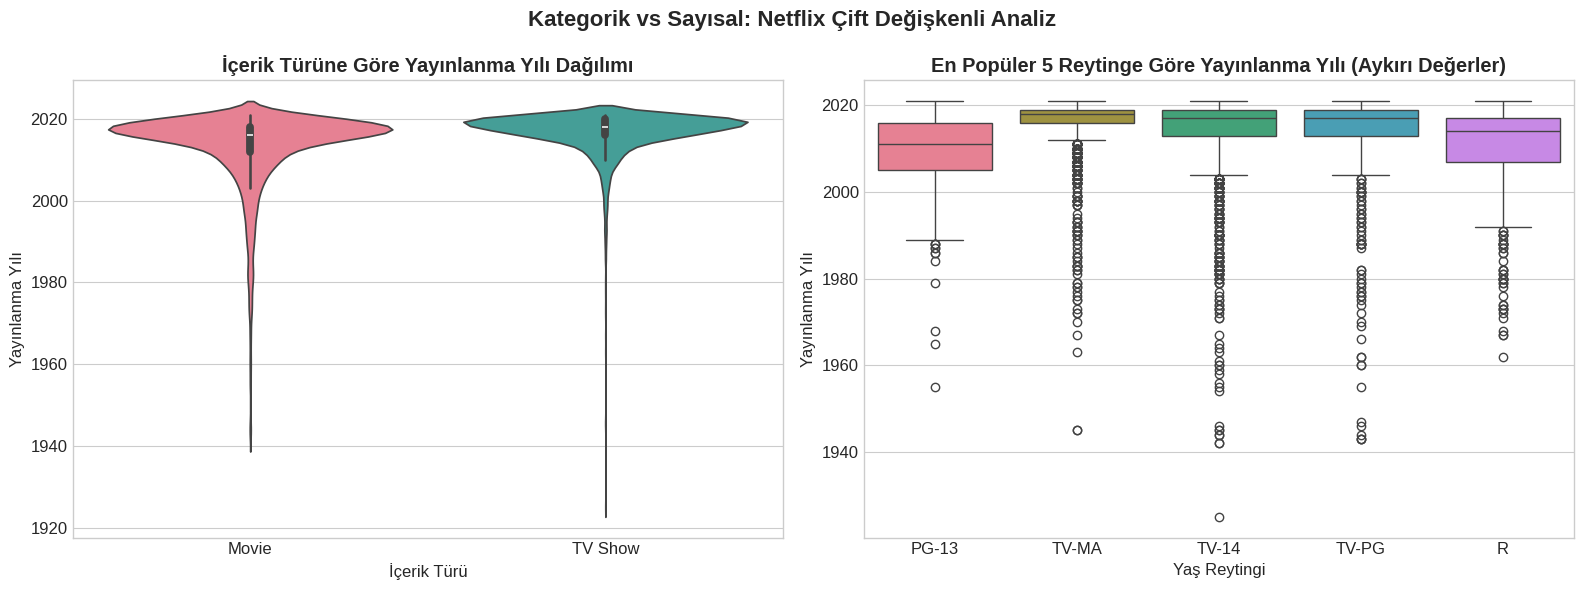

In [ ]:
# kategorik vs sayısal

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. GRAFİK (Violin Plot): İÇERİK TÜRÜ (Type) vs YAYINLANMA YILI

# Violin plot (Keman grafiği), verinin hangi yıllarda yoğunlaştığını (şişkinleştiğini) harika gösterir
# Not: Yeni Seaborn sürümlerinde hata almamak için x'e verdiğimiz değeri hue'ya da verip legend=False yapıyoruz
sns.violinplot(data=df_temiz, x='type', y='release_year', hue='type', legend=False, ax=axes[0], palette='husl')

axes[0].set_title('İçerik Türüne Göre Yayınlanma Yılı Dağılımı', fontweight='bold')
axes[0].set_xlabel('İçerik Türü')
axes[0].set_ylabel('Yayınlanma Yılı')



# 2. GRAFİK (Box Plot): REYTİNG (Rating) vs YAYINLANMA YILI
# Çok fazla reyting olduğu için grafiği sadece "İlk 5" popüler reyting için çizdiriyoruz
en_populer_reytingler = df_temiz['rating'].value_counts().head(5).index
df_rating = df_temiz[df_temiz['rating'].isin(en_populer_reytingler)]

sns.boxplot(data=df_rating, x='rating', y='release_year', hue='rating', legend=False, ax=axes[1], palette='husl')

axes[1].set_title('En Popüler 5 Reytinge Göre Yayınlanma Yılı (Aykırı Değerler)', fontweight='bold')
axes[1].set_xlabel('Yaş Reytingi')
axes[1].set_ylabel('Yayınlanma Yılı')


# Genel Düzenlemeler
plt.suptitle('Kategorik vs Sayısal: Netflix Çift Değişkenli Analiz', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

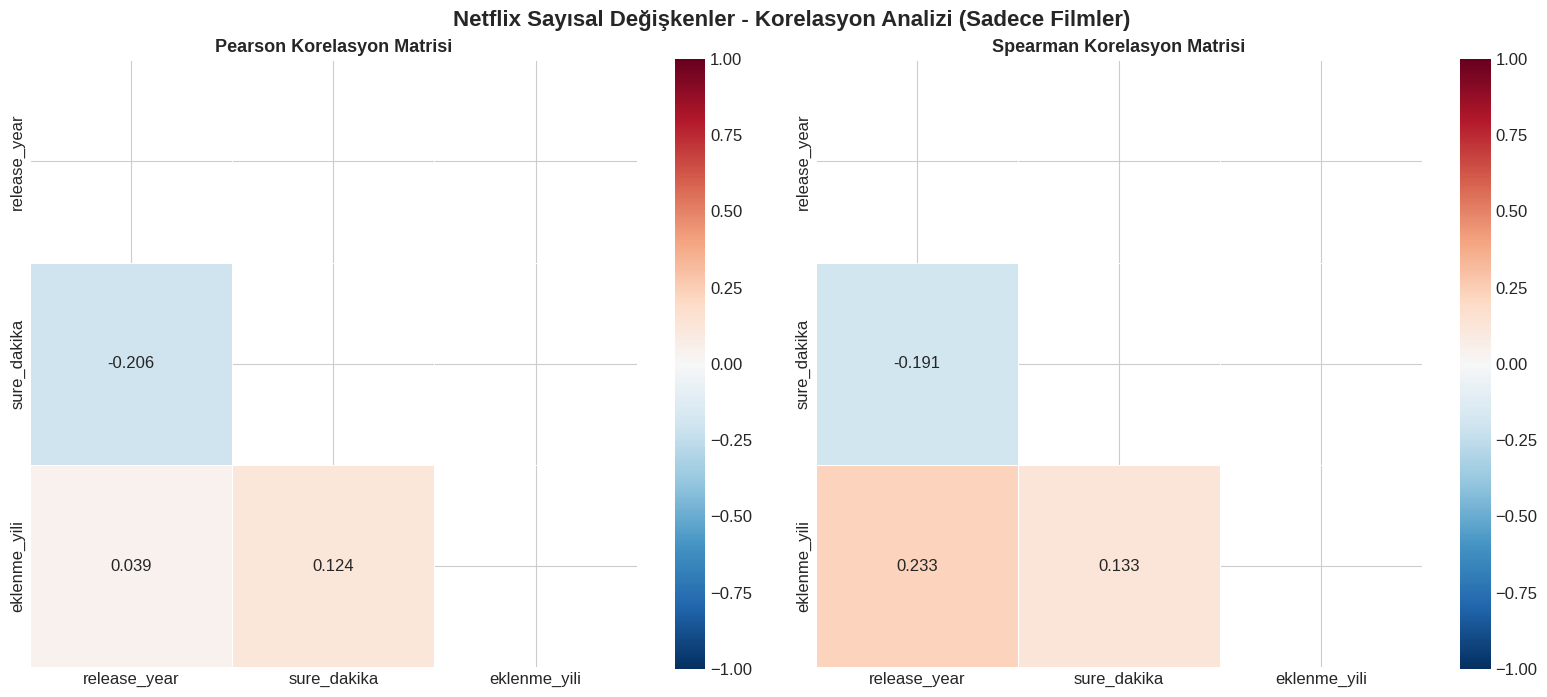

In [ ]:

# 1. VERİ HAZIRLIĞI (Yeni Sayısal Değişkenler Üretiyoruz)

# Sadece filmleri alıyoruz
filmler = df_temiz[df_temiz['type'] == 'Movie'].copy()

# A) Süreyi sayısal yapıyoruz (Örn: '90 min' -> 90.0)
filmler['sure_dakika'] = filmler['duration'].str.replace(' min', '').astype(float)

# B) Netflix'e eklenme tarihinden sadece YILI çekip sayısal yapıyoruz
filmler['eklenme_yili'] = pd.to_datetime(filmler['date_added'], errors='coerce').dt.year

# Şimdi elimizde 3 tane gerçek sayısal sütun oldu!
sayisal_df = filmler[['release_year', 'sure_dakika', 'eklenme_yili']]

# 2. GRAFİK ÇİZİMİ (Sizin kodunuzun Netflix'e uyarlanmış hali)
# Figür ve eksenleri tanımlıyoruz (Kodunuzda bu satır eksikti, ekledim)
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# PEARSON KORELASYONU
pearson_corr = sayisal_df.corr(method='pearson')

# Üst üçgeni gizlemek için maske oluşturma (Kendi yazdığınız harika mantık)
mask = np.triu(np.ones_like(pearson_corr, dtype=bool))

sns.heatmap(pearson_corr,
            mask=mask,
            annot=True,
            fmt='.3f',
            cmap='RdBu_r', # Kırmızı-Mavi renk paleti
            center=0,
            square=True,
            linewidths=0.5,
            ax=axes[0],
            vmin=-1, vmax=1)
axes[0].set_title('Pearson Korelasyon Matrisi', fontsize=13, fontweight='bold')


# SPEARMAN KORELASYONU
spearman_corr = sayisal_df.corr(method='spearman')

sns.heatmap(spearman_corr,
            mask=mask,
            annot=True,
            fmt='.3f',
            cmap='RdBu_r',
            center=0,
            square=True,
            linewidths=0.5,
            ax=axes[1],
            vmin=-1, vmax=1)
axes[1].set_title('Spearman Korelasyon Matrisi', fontsize=13, fontweight='bold')


plt.suptitle('Netflix Sayısal Değişkenler - Korelasyon Analizi (Sadece Filmler)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

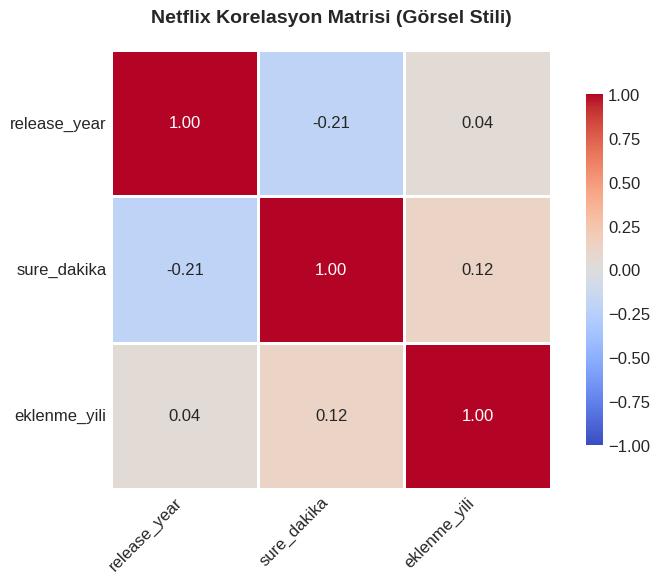

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Veri Hazırlığı (Sayısal değişkenleri oluşturduğumuz kısım)
filmler = df_temiz[df_temiz['type'] == 'Movie'].copy()
filmler['sure_dakika'] = filmler['duration'].str.replace(' min', '').astype(float)
filmler['eklenme_yili'] = pd.to_datetime(filmler['date_added'], errors='coerce').dt.year

# Sadece sayısal sütunları seçiyoruz
sayisal_df = filmler[['release_year', 'sure_dakika', 'eklenme_yili']]

# Korelasyonu hesaplıyoruz
corr_matrisi = sayisal_df.corr(method='pearson')

# 2. Grafik Çizimi (Görseldeki stile uygun)
plt.figure(figsize=(8, 6)) # 3 sütun olduğu için boyutu biraz küçülttük

sns.heatmap(corr_matrisi,
            annot=True,              # Kutuların içine sayıları yazdırır
            fmt='.2f',               # Görseldeki gibi virgülden sonra 2 hane gösterir
            cmap='coolwarm',         # Görseldeki gibi Mavi-Beyaz-Kırmızı renk paleti
            square=True,             # Kutuların tam kare olmasını sağlar
            linewidths=2,            # Görseldeki gibi kutular arasına kalın çizgi ekler
            linecolor='white',       # Çizgilerin rengini beyaz yapar
            vmin=-1, vmax=1,         # Renk skalasını -1 ve 1 arasına sabitler
            cbar_kws={"shrink": .8}) # Sağdaki renk çubuğunun boyutunu ayarlar

plt.title('Netflix Korelasyon Matrisi (Görsel Stili)', fontsize=14, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right') # Alt yazıları hafif yatırır
plt.yticks(rotation=0)              # Yan yazıları düz tutar

plt.tight_layout()
plt.show()

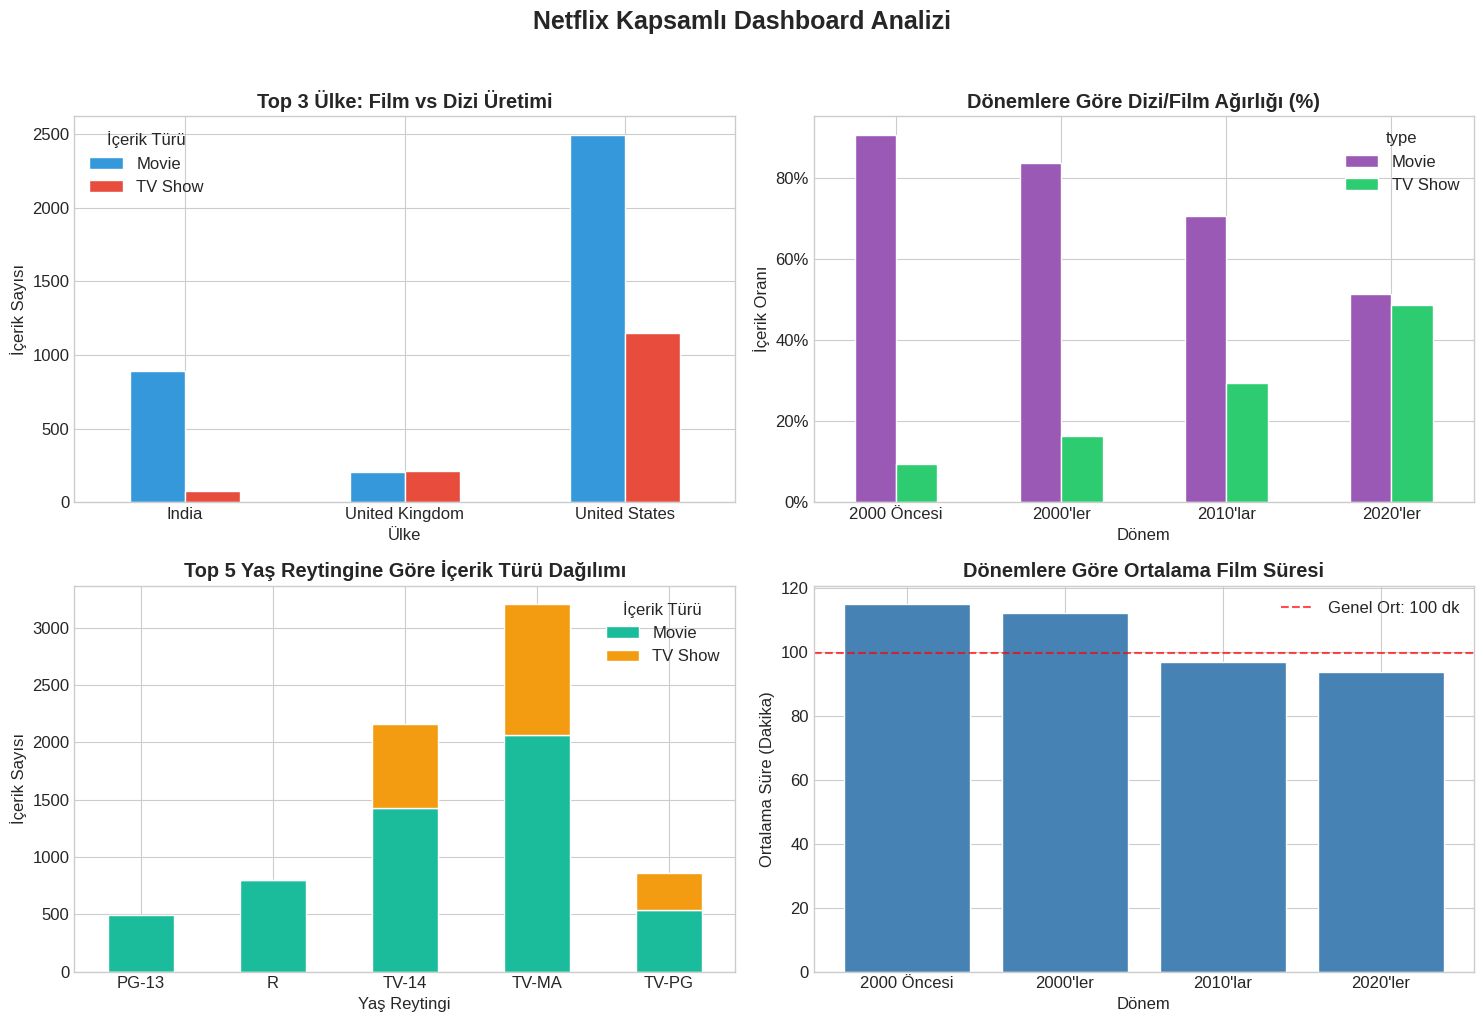

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# --- Veri Ön Hazırlık ---
# Süreleri (dakika) sayısallaştırma (4. grafik için)
df_temiz['sure_dakika'] = df_temiz['duration'].apply(lambda x: float(x.replace(' min', '')) if isinstance(x, str) and 'min' in x else np.nan)

# Yaş grubu yerine "Dönem/On Yıl" grubu oluşturma (2. ve 4. grafik için)
df_temiz['donem'] = pd.cut(df_temiz['release_year'],
                           bins=[1900, 1999, 2009, 2019, 2030],
                           labels=['2000 Öncesi', '2000\'ler', '2010\'lar', '2020\'ler'])

# --- Grafik Çizimi Başlıyor ---
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. GRAFİK: Top 3 Ülke ve İçerik Türü Üretimi
top3_ulke = df_temiz['country'].value_counts().head(3).index
df_top3 = df_temiz[df_temiz['country'].isin(top3_ulke)]
pivot1 = df_top3.groupby(['country', 'type']).size().unstack(fill_value=0)

pivot1.plot(kind='bar', ax=axes[0, 0], color=['#3498db', '#e74c3c'], edgecolor='white')
axes[0, 0].set_title('Top 3 Ülke: Film vs Dizi Üretimi', fontweight='bold')
axes[0, 0].set_xlabel('Ülke')
axes[0, 0].set_ylabel('İçerik Sayısı')
axes[0, 0].legend(title='İçerik Türü')
axes[0, 0].set_xticklabels(axes[0, 0].get_xticklabels(), rotation=0)


# 2. GRAFİK: Dönemlere (Yıllara) Göre İçerik Türü Trendi
pivot2 = df_temiz.groupby(['donem', 'type']).size().unstack(fill_value=0)
pivot2_yuzde = pivot2.div(pivot2.sum(axis=1), axis=0) # Oransal bakmak için

pivot2_yuzde.plot(kind='bar', ax=axes[0, 1], color=['#9b59b6', '#2ecc71'], edgecolor='white')
axes[0, 1].set_title('Dönemlere Göre Dizi/Film Ağırlığı (%)', fontweight='bold')
axes[0, 1].set_xlabel('Dönem')
axes[0, 1].set_ylabel('İçerik Oranı')
axes[0, 1].set_xticklabels(axes[0, 1].get_xticklabels(), rotation=0)
axes[0, 1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))


# 3. GRAFİK: Top 5 Reyting Dağılımı (Stacked Bar)
top5_rating = df_temiz['rating'].value_counts().head(5).index
df_rating = df_temiz[df_temiz['rating'].isin(top5_rating)]
pivot3 = df_rating.groupby(['rating', 'type']).size().unstack(fill_value=0)

pivot3.plot(kind='bar', stacked=True, ax=axes[1, 0], color=['#1abc9c', '#f39c12'], edgecolor='white')
axes[1, 0].set_title('Top 5 Yaş Reytingine Göre İçerik Türü Dağılımı', fontweight='bold')
axes[1, 0].set_xlabel('Yaş Reytingi')
axes[1, 0].set_ylabel('İçerik Sayısı')
axes[1, 0].legend(title='İçerik Türü')
axes[1, 0].set_xticklabels(axes[1, 0].get_xticklabels(), rotation=0)


# 4. GRAFİK: Dönemlere Göre Ortalama Film Süresi
donem_sure = df_temiz.dropna(subset=['sure_dakika']).groupby('donem')['sure_dakika'].mean()

axes[1, 1].bar(donem_sure.index.astype(str), donem_sure.values, color='steelblue', edgecolor='white')
axes[1, 1].set_title('Dönemlere Göre Ortalama Film Süresi', fontweight='bold')
axes[1, 1].set_xlabel('Dönem')
axes[1, 1].set_ylabel('Ortalama Süre (Dakika)')

# Tüm filmlerin genel ortalamasını kesikli kırmızı çizgi ile çizdiriyoruz
genel_ortalama = df_temiz['sure_dakika'].mean()
axes[1, 1].axhline(genel_ortalama, color='red', linestyle='--', alpha=0.7, label=f'Genel Ort: {genel_ortalama:.0f} dk')
axes[1, 1].legend()

plt.suptitle('Netflix Kapsamlı Dashboard Analizi', fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# Sentetik zaman serisi oluştur
np.random.seed(42)
tarihler = pd.date_range(start='2022-01-01', end='2024-12-31', freq='D')
n = len(tarihler)

# Trend + Mevsimsellik + Gürültü
trend = np.linspace(100, 200, n)
mevsimsellik = 30 * np.sin(2 * np.pi * np.arange(n) / 365)
haftalik = 10 * np.sin(2 * np.pi * np.arange(n) / 7)
gurultu = np.random.normal(0, 15, n)

degerler = trend + mevsimsellik + haftalik + gurultu

ts_df = pd.DataFrame({
    'tarih': tarihler,
    'satis': np.maximum(degerler, 0).round(2)
})
ts_df.set_index('tarih', inplace=True)

print('📅 Zaman Serisi Veri Seti Oluşturuldu!')
print(f'Toplam gün sayısı: {len(ts_df)}')
print(ts_df.head())

📅 Zaman Serisi Veri Seti Oluşturuldu!
Toplam gün sayısı: 1096
            satis
tarih            
2022-01-01 107.45
2022-01-02 106.35
2022-01-03 120.68
2022-01-04 129.01
2022-01-05  94.58


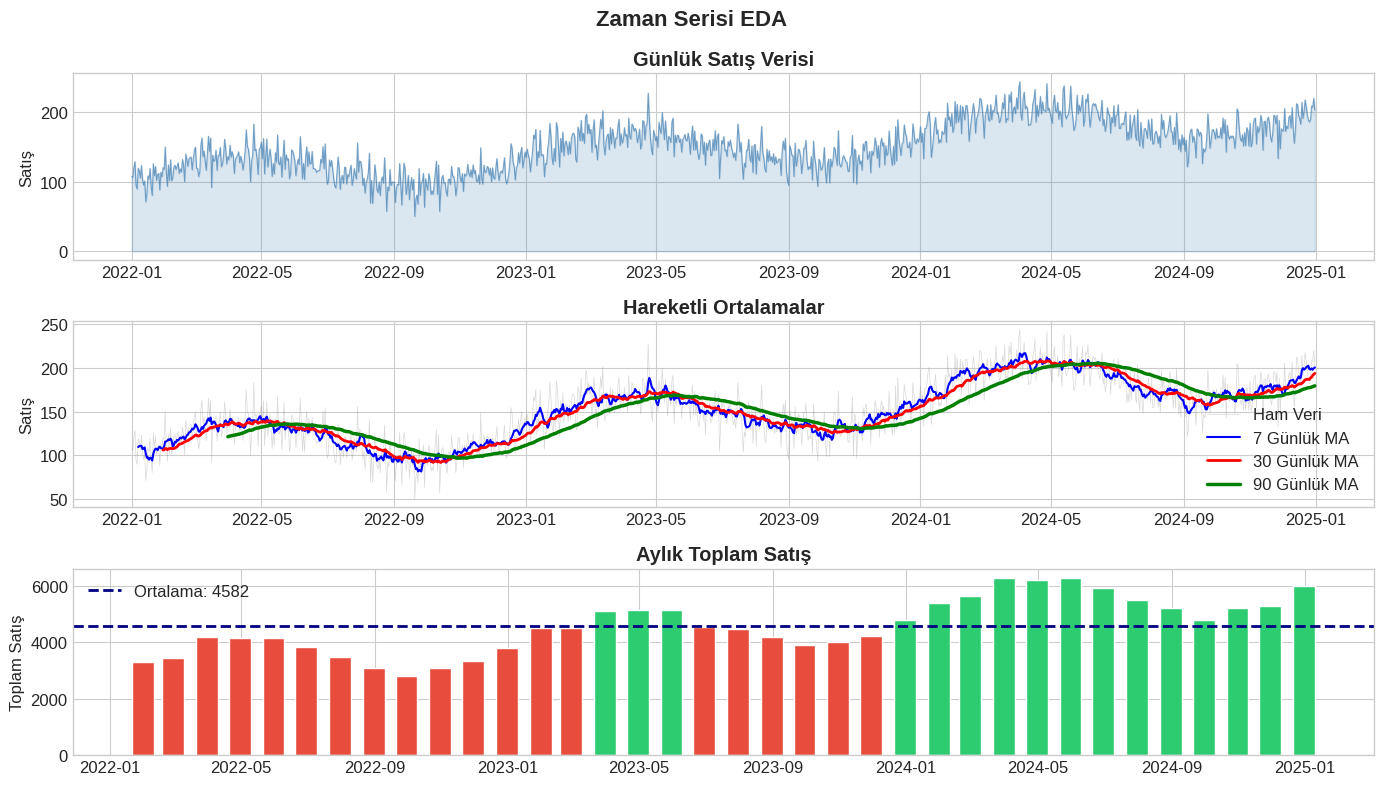

In [ ]:
# Zaman serisi görselleştirme
fig, axes = plt.subplots(3, 1, figsize=(14, 8))

# Ham seri
axes[0].plot(ts_df.index, ts_df['satis'], color='steelblue', alpha=0.7, linewidth=0.8)
axes[0].set_title('Günlük Satış Verisi', fontweight='bold')
axes[0].set_ylabel('Satış')
axes[0].fill_between(ts_df.index, ts_df['satis'], alpha=0.2, color='steelblue')

# Hareketli ortalama
ts_df['MA_7'] = ts_df['satis'].rolling(window=7).mean()
ts_df['MA_30'] = ts_df['satis'].rolling(window=30).mean()
ts_df['MA_90'] = ts_df['satis'].rolling(window=90).mean()

axes[1].plot(ts_df.index, ts_df['satis'], alpha=0.3, color='gray', linewidth=0.5, label='Ham Veri')
axes[1].plot(ts_df.index, ts_df['MA_7'], color='blue', linewidth=1.5, label='7 Günlük MA')
axes[1].plot(ts_df.index, ts_df['MA_30'], color='red', linewidth=2, label='30 Günlük MA')
axes[1].plot(ts_df.index, ts_df['MA_90'], color='green', linewidth=2.5, label='90 Günlük MA')
axes[1].set_title('Hareketli Ortalamalar', fontweight='bold')
axes[1].set_ylabel('Satış')
axes[1].legend()

# Aylık toplam
aylik = ts_df['satis'].resample('ME').sum()
colors_aylik = ['#2ecc71' if x > aylik.mean() else '#e74c3c' for x in aylik.values]
axes[2].bar(aylik.index, aylik.values, color=colors_aylik, width=20, edgecolor='white')
axes[2].axhline(aylik.mean(), color='navy', linestyle='--', linewidth=2, label=f'Ortalama: {aylik.mean():.0f}')
axes[2].set_title('Aylık Toplam Satış', fontweight='bold')
axes[2].set_ylabel('Toplam Satış')
axes[2].legend()

plt.suptitle('Zaman Serisi EDA', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

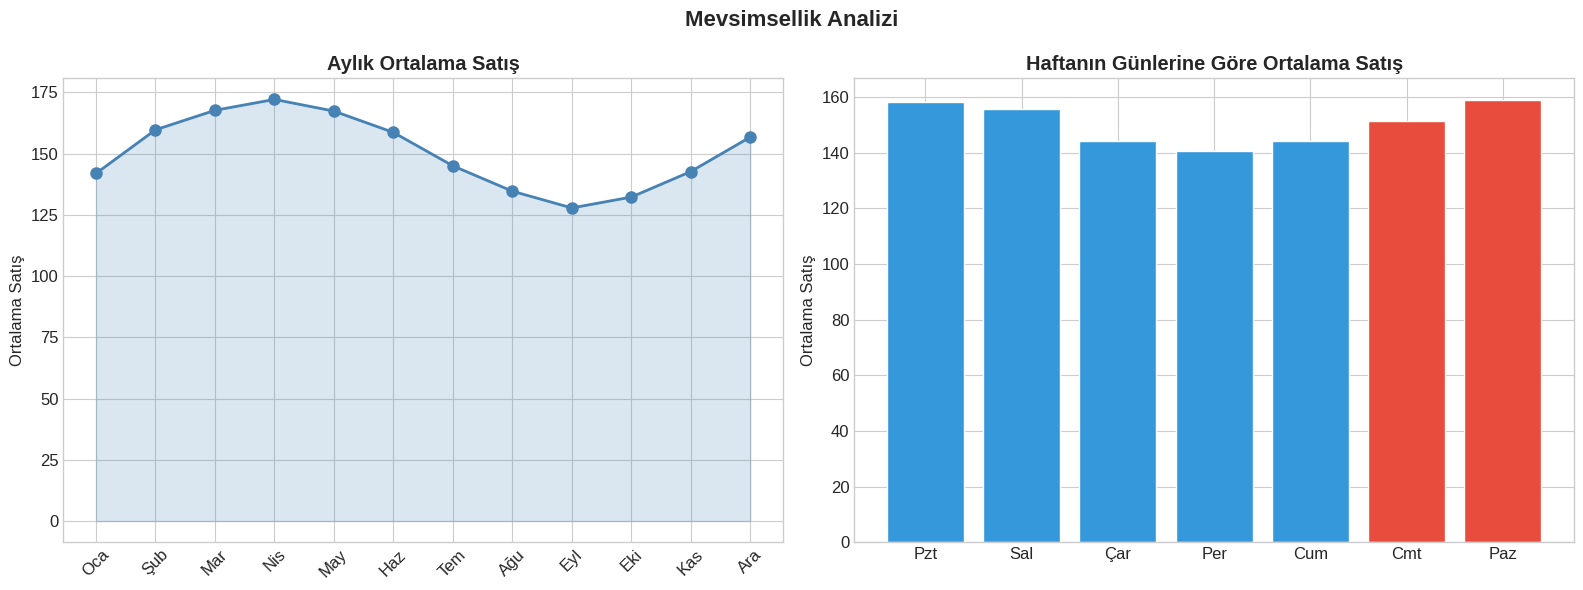

In [ ]:
# Mevsimsellik analizi
ts_df['ay'] = ts_df.index.month
ts_df['gun_adi'] = ts_df.index.day_name()
ts_df['yil'] = ts_df.index.year

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Aylık ortalama
ay_isimleri = ['Oca', 'Şub', 'Mar', 'Nis', 'May', 'Haz',
               'Tem', 'Ağu', 'Eyl', 'Eki', 'Kas', 'Ara']
aylik_ort = ts_df.groupby('ay')['satis'].mean()
axes[0].plot(range(1, 13), aylik_ort.values, 'o-', color='steelblue', linewidth=2, markersize=8)
axes[0].fill_between(range(1, 13), aylik_ort.values, alpha=0.2, color='steelblue')
axes[0].set_xticks(range(1, 13))
axes[0].set_xticklabels(ay_isimleri, rotation=45)
axes[0].set_title('Aylık Ortalama Satış', fontweight='bold')
axes[0].set_ylabel('Ortalama Satış')

# Haftanın günlerine göre ortalama
gun_sirasi = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
gun_isimleri_tr = ['Pzt', 'Sal', 'Çar', 'Per', 'Cum', 'Cmt', 'Paz']
haftalik_ort = ts_df.groupby('gun_adi')['satis'].mean().reindex(gun_sirasi)
renkler_hafta = ['#3498db'] * 5 + ['#e74c3c'] * 2
axes[1].bar(gun_isimleri_tr, haftalik_ort.values, color=renkler_hafta, edgecolor='white')
axes[1].set_title('Haftanın Günlerine Göre Ortalama Satış', fontweight='bold')
axes[1].set_ylabel('Ortalama Satış')

plt.suptitle('Mevsimsellik Analizi', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()